In [1]:
import os
import pandas as pd
import numpy as np
import pickle
from tqdm import tqdm
import seaborn as sns
from scipy.spatial.distance import cdist
import matplotlib.pyplot as plt

def get_node_region(point, detail=False):
    p = point[['x', 'y', 'z']].copy()
    p['x'] = np.floor(p['x'] / nmt.annotation.space['x'])
    p['y'] = np.floor(p['y'] / nmt.annotation.space['y'])
    p['z'] = np.floor(p['z'] / nmt.annotation.space['z'])
    
    p = p.round(0).astype(int)
    if ((p.x.iloc[0] >= 0) & (p.x.iloc[0] < nmt.annotation.size['x']) &
            (p.y.iloc[0] >= 0) & (p.y.iloc[0] < nmt.annotation.size['y']) &
            (p.z.iloc[0] >= 0) & (p.z.iloc[0] < nmt.annotation.size['z'])
    ):
        region_id = nmt.annotation.array[p.x.iloc[0],
                                         p.y.iloc[0],
                                         p.z.iloc[0]]
        if region_id in list(nmt.bs.dict_to_selected.keys()):
            if not detail:
                region_id = nmt.bs.dict_to_selected[region_id]
            region = nmt.bs.id_to_name(region_id)
            return region

    return 'unknow'

def readSWC(swc_path, mode='simple'):
    n_skip = 0
    with open(swc_path, "r") as f:
        for line in f.readlines():
            line = line.strip()
            if line.startswith("#"):
                n_skip += 1
            else:
                break
    names = ["##n", "type", "x", "y", "z", "r", "parent"]
    used_cols = [0, 1, 2, 3, 4, 5, 6]
    if mode == 'simple':
        pass
    df = pd.read_csv(swc_path, index_col=0, skiprows=n_skip, sep=" ",
                     usecols=used_cols,
                     names=names
                     )

    return df

In [10]:
def func(tmp_branch_index, tmp_swc, tmp_den_id):
    try:
        tmp_results = []
        tmp_nodelist = []
        tmp_branch2length = {}
        cur_index = tmp_den_id
        while cur_index not in tmp_branch_index:
            if cur_index == -1:
                break
            tmp_nodelist.append(cur_index)
            cur_index = tmp_swc.loc[cur_index, 'parent']

        if (len(tmp_nodelist) == 0):
            tmp_results.append([tmp_den_id, 0, -1, -10])
        elif (len(tmp_nodelist) == 1) and (tmp_swc.loc[tmp_nodelist[0], 'parent'] == -1):
            tmp_results.append([tmp_den_id, 0, -1, -20])
        else:
            if cur_index == -1:
                tmp_nodelist = tmp_nodelist[:-1]
            tmp_parentlist = list(tmp_swc.loc[tmp_nodelist, 'parent'])

            tmp_delta = (tmp_swc.loc[tmp_nodelist, ['x', 'y', 'z']].values - tmp_swc.loc[
                tmp_parentlist, ['x', 'y', 'z']].values)
            tmp_dis = np.sum(np.sqrt(np.sum(tmp_delta * tmp_delta, axis=1)))
            # 计算branch整体长度
            if tmp_nodelist[-1] in list(tmp_branch2length.keys()):
                tmp_results.append([tmp_den_id, tmp_dis, tmp_branch2length[tmp_nodelist[-1]], tmp_nodelist[-1]])
            else:
                cur_start = tmp_nodelist[-1]
                tmp_list = [tmp_nodelist[-1]]
                while cur_start not in tmp_branch_index:
                    cur_start = tmp_swc.loc[tmp_swc['parent'] == cur_start].index
                    if len(cur_start) == 1:
                        cur_start = cur_start[0]
                        tmp_list.append(cur_start)
                    else:
                        break
                tmp_parentlist = tmp_swc.loc[tmp_list, 'parent']
                tmp_delta = (tmp_swc.loc[tmp_list, ['x', 'y', 'z']].values - tmp_swc.loc[
                    tmp_parentlist, ['x', 'y', 'z']].values)
                tmp_branch2length[tmp_nodelist[-1]] = np.sum(np.sqrt(np.sum(tmp_delta * tmp_delta, axis=1)))
                tmp_results.append([tmp_den_id, tmp_dis, tmp_branch2length[tmp_nodelist[-1]], tmp_nodelist[-1]])
    except:
        print(tmp_den_id, 'fail')
        tmp_results = [[tmp_den_id, -1, -1, -30]]
    return tmp_results

In [ ]:
swc_dataset = '../../data/processed_neuron_nmo'
swc_list = os.listdir(swc_dataset)

tmp_concatlist = []
for i in (swc_list):
    tmp_swc = pd.read_csv(swc_dataset+'/'+i, 
                        sep=' ', index_col=0, skiprows=1, header=None, 
                        names=['##n', 'type', 'x', 'y', 'z', 'r', 'parent', 
                               'spine','inh'],
                        usecols=[0,1,2,3,4,5,6, 
                                 7, 8]
                       )
    tmp_swc = tmp_swc[['type', 'x', 'y', 'z', 'r', 'parent', 'spine', 'inh']]
    tmp_swc['synapse'] = -1
    tmp_swc.loc[tmp_swc[tmp_swc['spine']>0].index, 'synapse'] = 1
    tmp_swc.loc[tmp_swc[tmp_swc['inh']>0].index, 'synapse'] = 1

    tmp_den = tmp_swc[tmp_swc['synapse'] == 1].copy()
    tmp_den['cell_id'] = i
    tmp_ct = tmp_swc['parent'].value_counts()
    tmp_ct = tmp_ct[tmp_ct == 2]
    tmp_branch_index = list(tmp_ct.index)

    tmp_results = []
    for j in tqdm(tmp_den.index):
        tmp_results.append(func(tmp_branch_index, tmp_swc, j))

    tmp_den[['swc_id']] = i
    tmp_den[['branch_dis']] = -1.0
    tmp_den[['branch_length']] = -1.0
    tmp_den[['branch_id']] = -1.0
    cur_indexlist = [xi[0][0] for xi in tmp_results]
    cur_branch_dis_list = [xi[0][1] for xi in tmp_results]
    cur_branch_length_list = [xi[0][2] for xi in tmp_results]
    cur_branch_id_list = [xi[0][3] for xi in tmp_results]

    tmp_den.loc[cur_indexlist, ['branch_dis']] = cur_branch_dis_list
    tmp_den.loc[cur_indexlist, ['branch_length']] = cur_branch_length_list
    tmp_den.loc[cur_indexlist, ['branch_id']] = cur_branch_id_list

    tmp_concatlist.append(tmp_den)


 75%|██████████████████████████████████████████████████████████▋                   | 5374/7141 [12:01<04:02,  7.29it/s]

29923 fail


 76%|███████████████████████████████████████████████████████████                   | 5402/7141 [12:05<04:16,  6.78it/s]

30062 fail


 76%|███████████████████████████████████████████████████████████                   | 5407/7141 [12:06<03:04,  9.41it/s]

...

 76%|███████████████████████████████████████████████████████████                   | 5411/7141 [12:06<03:16,  8.81it/s]

30097 fail


 76%|███████████████████████████████████████████████████████████▏                  | 5419/7141 [12:07<02:31, 11.34it/s]

30128 fail


 77%|███████████████████████████████████████████████████████████▊                  | 5474/7141 [12:15<04:37,  6.00it/s]

In [ ]:
den_contact = pd.concat(tmp_concatlist, axis=0)
den_contact

In [ ]:
den_contact.to_csv('../../output/iascone_data_branch_inner_distribution.csv', sep=',')

In [2]:
den_contact = pd.read_csv('../../output/iascone_data_branch_inner_distribution.csv', sep=',', index_col=0)
den_contact

,type,x,y,z,r,parent,spine,inh,synapse,cell_id,swc_id,branch_dis,branch_length,branch_id,ratio
##n,,,,,,,,,,,,,,,
88,start,880.050,1082.70,137.685,55.240,82,-1.0,1.0,1,processed_Neuron-1-E-and-I-synapses.eswc.swc,processed_Neuron-1-E-and-I-synapses.eswc.swc,14.603168,288.550664,4.0,0.050609
470,start,879.947,1140.76,190.025,9.084,463,-1.0,1.0,1,processed_Neuron-1-E-and-I-synapses.eswc.swc,processed_Neuron-1-E-and-I-synapses.eswc.swc,36.462877,127.442337,218.0,0.286113
512,middle,879.884,1141.67,195.928,9.293,505,1.0,-1.0,1,processed_Neuron-1-E-and-I-synapses.eswc.swc,processed_Neuron-1-E-and-I-synapses.eswc.swc,42.456415,127.442337,218.0,0.333142
519,middle,879.872,1141.78,196.922,9.356,512,1.0,-1.0,1,processed_Neuron-1-E-and-I-synapses.eswc.swc,processed_Neuron-1-E-and-I-synapses.eswc.swc,43.456555,127.442337,218.0,0.340990
534,start,868.690,1153.42,180.339,9.964,527,-1.0,1.0,1,processed_Neuron-1-E-and-I-synapses.eswc.swc,processed_Neuron-1-E-and-I-synapses.eswc.swc,45.244351,598.022062,219.0,0.075657
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
41913,end,-1141.070,1388.88,-95.849,1.990,41912,1.0,-1.0,1,processed_Neuron-9-E-and-I-synapses.eswc.swc,processed_Neuron-9-E-and-I-synapses.eswc.swc,1375.087741,1380.029815,32542.0,0.996419
41914,end,-1141.950,1388.76,-95.382,1.873,41913,-1.0,1.0,1,processed_Neuron-9-E-and-I-synapses.eswc.swc,processed_Neuron-9-E-and-I-synapses.eswc.swc,1376.091180,1380.029815,32542.0,0.997146
41915,end,-1142.710,1388.59,-94.842,1.762,41914,1.0,-1.0,1,processed_Neuron-9-E-and-I-synapses.eswc.swc,processed_Neuron-9-E-and-I-synapses.eswc.swc,1377.038861,1380.029815,32542.0,0.997833


In [3]:
den_contact['ratio'] = den_contact['branch_dis'] / den_contact['branch_length']
den_contact

,type,x,y,z,r,parent,spine,inh,synapse,cell_id,swc_id,branch_dis,branch_length,branch_id,ratio
##n,,,,,,,,,,,,,,,
88,start,880.050,1082.70,137.685,55.240,82,-1.0,1.0,1,processed_Neuron-1-E-and-I-synapses.eswc.swc,processed_Neuron-1-E-and-I-synapses.eswc.swc,14.603168,288.550664,4.0,0.050609
470,start,879.947,1140.76,190.025,9.084,463,-1.0,1.0,1,processed_Neuron-1-E-and-I-synapses.eswc.swc,processed_Neuron-1-E-and-I-synapses.eswc.swc,36.462877,127.442337,218.0,0.286113
512,middle,879.884,1141.67,195.928,9.293,505,1.0,-1.0,1,processed_Neuron-1-E-and-I-synapses.eswc.swc,processed_Neuron-1-E-and-I-synapses.eswc.swc,42.456415,127.442337,218.0,0.333142
519,middle,879.872,1141.78,196.922,9.356,512,1.0,-1.0,1,processed_Neuron-1-E-and-I-synapses.eswc.swc,processed_Neuron-1-E-and-I-synapses.eswc.swc,43.456555,127.442337,218.0,0.340990
534,start,868.690,1153.42,180.339,9.964,527,-1.0,1.0,1,processed_Neuron-1-E-and-I-synapses.eswc.swc,processed_Neuron-1-E-and-I-synapses.eswc.swc,45.244351,598.022062,219.0,0.075657
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
41913,end,-1141.070,1388.88,-95.849,1.990,41912,1.0,-1.0,1,processed_Neuron-9-E-and-I-synapses.eswc.swc,processed_Neuron-9-E-and-I-synapses.eswc.swc,1375.087741,1380.029815,32542.0,0.996419
41914,end,-1141.950,1388.76,-95.382,1.873,41913,-1.0,1.0,1,processed_Neuron-9-E-and-I-synapses.eswc.swc,processed_Neuron-9-E-and-I-synapses.eswc.swc,1376.091180,1380.029815,32542.0,0.997146
41915,end,-1142.710,1388.59,-94.842,1.762,41914,1.0,-1.0,1,processed_Neuron-9-E-and-I-synapses.eswc.swc,processed_Neuron-9-E-and-I-synapses.eswc.swc,1377.038861,1380.029815,32542.0,0.997833


In [4]:
den_contact[['type']] = 'n'
den_contact.loc[den_contact['ratio']>=0.66, 'type'] = 'Distal'
den_contact.loc[den_contact['ratio']<=0.33, 'type'] = 'Proximal'
den_contact.loc[(den_contact['ratio']>0.33)&(den_contact['ratio']<0.66), 'type'] = 'Middle'

In [5]:
long_df = pd.crosstab(den_contact['swc_id'], den_contact['type']).stack().reset_index()
long_df.columns = ['target_cell', 'type', 'counts']
long_df

,target_cell,type,counts
0,processed_Neuron-1-E-and-I-synapses.eswc.swc,Distal,3197
1,processed_Neuron-1-E-and-I-synapses.eswc.swc,Middle,2961
2,processed_Neuron-1-E-and-I-synapses.eswc.swc,Proximal,2848
3,processed_Neuron-10-E-and-I-synapses.eswc.swc,Distal,2631
4,processed_Neuron-10-E-and-I-synapses.eswc.swc,Middle,2544
5,processed_Neuron-10-E-and-I-synapses.eswc.swc,Proximal,2275
6,processed_Neuron-11-E-synapses.eswc.swc,Distal,2433
7,processed_Neuron-11-E-synapses.eswc.swc,Middle,2489
8,processed_Neuron-11-E-synapses.eswc.swc,Proximal,2284
9,processed_Neuron-12-E-synapses.eswc.swc,Distal,2084


In [6]:
long_df['probability'] = long_df['counts'].copy()

for i in np.unique(long_df['target_cell']):
    tmp_df = long_df[long_df['target_cell'] == i]
    tmp_sum = np.sum(tmp_df['counts'])
    long_df.loc[tmp_df.index, 'probability'] = long_df.loc[tmp_df.index, 'probability'] / tmp_sum

long_df

C:\Users\yishui\AppData\Local\Temp\ipykernel_36008\1003667237.py:6: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '[0.35498557 0.32878081 0.31623362]' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  long_df.loc[tmp_df.index, 'probability'] = long_df.loc[tmp_df.index, 'probability'] / tmp_sum


,target_cell,type,counts,probability
0,processed_Neuron-1-E-and-I-synapses.eswc.swc,Distal,3197,0.354986
1,processed_Neuron-1-E-and-I-synapses.eswc.swc,Middle,2961,0.328781
2,processed_Neuron-1-E-and-I-synapses.eswc.swc,Proximal,2848,0.316234
3,processed_Neuron-10-E-and-I-synapses.eswc.swc,Distal,2631,0.353154
4,processed_Neuron-10-E-and-I-synapses.eswc.swc,Middle,2544,0.341477
5,processed_Neuron-10-E-and-I-synapses.eswc.swc,Proximal,2275,0.305369
6,processed_Neuron-11-E-synapses.eswc.swc,Distal,2433,0.337635
7,processed_Neuron-11-E-synapses.eswc.swc,Middle,2489,0.345407
8,processed_Neuron-11-E-synapses.eswc.swc,Proximal,2284,0.316958
9,processed_Neuron-12-E-synapses.eswc.swc,Distal,2084,0.347333


C:\Users\yishui\AppData\Local\Temp\ipykernel_36008\3964794324.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=long_df, x='type', y='probability', fliersize=0, palette='tab10')


Text(16.47222222222222, 0.5, '%PPSSpac(per cell)')

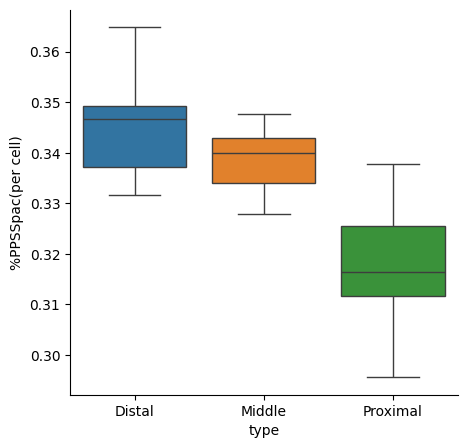

In [7]:
f,ax = plt.subplots(1,1,figsize=(5,5))
sns.boxplot(data=long_df, x='type', y='probability', fliersize=0, palette='tab10')
plt.gca().spines['top'].set_visible(False)
plt.gca().spines['right'].set_visible(False)
plt.savefig('./branch_inner_distribution_iascone.svg', bbox_inches='tight')

plt.ylabel("%PPSSpac(per cell)")
# plt.ylim([0, 100])